# **Analyse Projekt Parkinson**

## Inhaltsverzeichnis
> [1. Einleitung](#einleitung)  
> [2. Datenimport, -bereinigung und erste Statistiken](#daten_interaktion)  
> [3. Explorative Datenanalyse (EDA)](#eda)  
> [4. Interpretation und Dokumentation](#interpretation_dokumentation)  
> [5. Schlussfolgerung](#schlussfolgerungen)


<a id="einleitung"></a>
## 1. Einleitung

Heute möchten wir uns einen demographischen Datensatz aus einer Datenbank zum Thema Parkinson anschauen. Die Datenbank finden wir __[HIER](https://physionet.org/content/gaitpdb/1.0.0/#files-panel)__ .  
Bei der Datenbank handelt es sich um eine Sammlung aus drei Studien (Galit Yogev et al., 2005; Silvi Frenkel-Toledo et al., 2005; Hausdorff et al., 2007). Die Studien wurden zu einer Datenbank zusammengeführt und 2008 von Jeffrey Hausdorff veröffentlicht. In den Studien wurden allgemeine und etablierte Tests für Parkinsonpatienten, Sensordaten und Personendaten der Probanden zusammengetragen. Wir werden uns auf die demographischen Daten und Testergebnisse konzentrieren. Diese sind in der Datei `demographics.xls` gespeichert.  
Die Daten stammen aus den USA und es sind 93 Patienten und 73 Kontrollpersonen im Datensatz vertreten.

Parkinson ist eine neurodegenerative Erkrankung die v.a. Männer betrifft. Meist ist eine Erstdiagnose zwischen dem 50. und 60. Lebensjahr zu beobachten. Bei der Erkrankung wird vor allem der Dopamintransport in den Nervenzellen Stück für Stück abgebaut. Dadurch entstehen Probleme bei der Reizweiterleitung. Klassische Symptome einer Parkinson-Erkrankung sind Hypokinese (verminderte Bewegungsamplitude), Akinese (hochgradige Bewegungsarmut) und Bradykinese (Bewegungsverlangsamung). Hierzu kommen oft auch Rigor (erhöhter Grundtonus der Muskulatur), Tremor (Zittern einzelner Extremitäten) und Gleichgewichtsstörungen. Im weiteren Verlauf können weitere sensorische, vegetative und psychische Symptome dazukommen.

Für die Einteilung des Schweregrads der Erkrankung haben sich die Hoehn und Yahr Skala (HoehnYahr) und die Unified Parkinson´s Disease Rating Scale (UPDRS) etabliert. Oft wird hier auch noch der Timed "Up and Go"-Test (TUAG oder TUG) genutzt.  

<hr>  
  
Die **HoehnYahr Skala** ist eine einfach Einteilung in Grade von 0 - 5 mit klaren Kriterien:
|Stadium|Klinik|
|---|---|
|0|Keine Krankheitsanzeichen|
|1|Einseitige Symptomatik|
|1.5|Einseitige Symptomatik und axiale Beteiligung|
|2|Beidseitige Symptomatik; keine Haltungsinstabilität|
|2.5|Leichte beidseitige Symptomatik; Patient kann beim Zugtest das Gleichgewicht wiederherstellen|
|3|Leichte bis mäßige beidseitige Symptomatik; leichte Haltungsinstabilität; Selbständigkeit erhalten|
|4|Starke Behinderung, Patient kann aber noch ohne Hilfe gehen und stehen|
|5|Patient ist ohne Hilfe von Dritten an den Rollstuhl gebunden oder bettlägerig|  

<hr>  

Der **UPDRS** ist in vier Teile unterteilt. Teil I & II sind Fragebögen, die der Patient ausfüllt (jeweils 13 Items). Teil III (UPDRS-M) ist eine motorische Untersuchung, in der der Untersuchende mit dem Patienten zusammen verschiedenste Items durchläuft und bewertet (18 Items). Teil IV besteht aus Aufforderungen, die der Patient ausführen muss (6 Items). Alle Items werden mit einem Punktesystem von 0 = normal bis 4 = schwer bewertet. Am Ende erhält der Patient eine Gesamtpunktzahl (max. 200 Punkte), die mit steigendem Wert einen schwereren Grad der Erkrankung aufzeigt.  

<hr>  

Der **TUAG** ist ein einfacher Test, der sehr gern für die Bewertung der Mobilität von Patienten genutzt wird. Die Ausführung ist schnell erklärt. Der Proband sitzt auf einem Stuhl. Auf Kommando des Untersuchenden steht der Proband auf und geht schnellstmöglich zu einer drei Meter entfernten Markierung. Dort angekommen dreht er um, kehrt zum Stuhl zurück und setzt sich wieder hin. Der Untersuchende stoppt hierbei die Zeit vom Startkommando bis der Proband wieder sitzt. Der Proband darf jedes Hilfsmittel für die Fortbewegung nutzen, jedoch keine manuelle Hilfe von anderen. Desto weniger Zeit er benötigt, umso besser ist das Ergebnis und die Mobilität des Probanden.

Im Datensatz werden wir einige Testergebnisse der soeben vorgestellten Test finden und die Angabe der Gehgeschwindigkeit, die die Probanden bei einem zweiminütigen Gehen auf ebener Strecke erreicht haben.  
Zugleich sind auch allgemeine Angaben über die Probanden wie Alter, Geschlecht, Größe und Gewicht enthalten.

Wir möchten heute tiefergehende Einblicke in die demographischen Daten bekommen und die Korrelation von verschiedenen Faktoren und deren Einfluss auf die Testergebnisse erforschen. Auch werden wir die Ergebnisse von den Patienten mit denen der Kontrollgruppe vergleichen und einige Hypothesen beantworten.

<a id="daten_interaktion"></a>
## 2. Datenimport, -bereinigung und erste Statistiken

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
%matplotlib inline

In [2]:
# Einlesen des Datensatzes.
pds_df = pd.read_excel("demographics.xls")
pds_df

,ID,Study,Group,Subjnum,Gender,Age,Height (meters),Weight (kg),HoehnYahr,UPDRS,UPDRSM,TUAG,Speed_01 (m/sec),Speed_10
0,GaPt03,Ga,PD,3,female,82,1.45,50.0,3.0,20.0,10.0,36.34,NaN,0.778
1,GaPt04,Ga,PD,4,male,68,1.71,NaN,2.5,25.0,8.0,11.00,0.642,0.818
2,GaPt05,Ga,PD,5,female,82,1.53,51.0,2.5,24.0,5.0,14.50,0.908,0.614
3,GaPt06,Ga,PD,6,male,72,1.70,82.0,2.0,16.0,13.0,10.47,0.848,0.937
4,GaPt07,Ga,PD,7,female,53,1.67,54.0,3.0,44.0,22.0,18.34,0.677,0.579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,SiCo26,Si,CO,26,male,60,1.74,72.0,NaN,NaN,NaN,9.20,1.000,NaN
162,SiCo27,Si,CO,27,male,67,1.90,95.0,NaN,NaN,NaN,12.52,1.120,NaN
163,SiCo28,Si,CO,28,male,61,1.70,72.0,NaN,NaN,NaN,12.65,0.990,NaN
164,SiCo29,Si,CO,29,male,53,1.70,87.0,NaN,NaN,NaN,11.41,1.290,NaN


Zuerst entfernen wir alle Spalten, die nicht benötigt werden. Die Spalte `Subjnum` dient nur der Nummerierung innerhalb der Studien und hat keine Relevanz für die Analyse. Ebenso hat die Spalte `Speed_10` sehr viele fehlende Daten, wodurch sie für die Analyse unbrauchbar wird.  
Damit die Arbeit mit dem Datensatz einfacher wird, werden wir alle Spaltenüberschriften klein schreiben und die Namen von `Height (meters)`, `Weight (kg)` und `Speed_01 (m/sec)` kürzen.

In [3]:
# Entfernen der irrelevanten Spalten.
pds_df.drop(columns=["Subjnum", "Speed_10"], inplace=True)

# Spaltennamen klein schreiben.
pds_df.columns = pds_df.columns.str.lower()

# Umbenennen der Spaltennamen zur besseren Verarbeitung.
pds_df = pds_df.rename(columns={"height (meters)": "height", "weight (kg)": "weight", "speed_01 (m/sec)": "walk_speed"})
pds_df

,id,study,group,gender,age,height,weight,hoehnyahr,updrs,updrsm,tuag,walk_speed
0,GaPt03,Ga,PD,female,82,1.45,50.0,3.0,20.0,10.0,36.34,NaN
1,GaPt04,Ga,PD,male,68,1.71,NaN,2.5,25.0,8.0,11.00,0.642
2,GaPt05,Ga,PD,female,82,1.53,51.0,2.5,24.0,5.0,14.50,0.908
3,GaPt06,Ga,PD,male,72,1.70,82.0,2.0,16.0,13.0,10.47,0.848
4,GaPt07,Ga,PD,female,53,1.67,54.0,3.0,44.0,22.0,18.34,0.677
...,...,...,...,...,...,...,...,...,...,...,...,...
161,SiCo26,Si,CO,male,60,1.74,72.0,NaN,NaN,NaN,9.20,1.000
162,SiCo27,Si,CO,male,67,1.90,95.0,NaN,NaN,NaN,12.52,1.120
163,SiCo28,Si,CO,male,61,1.70,72.0,NaN,NaN,NaN,12.65,0.990
164,SiCo29,Si,CO,male,53,1.70,87.0,NaN,NaN,NaN,11.41,1.290


### Falsche oder fehlende Werte anpassen

Wir betrachten den Datensatz genauer und sehen uns an, wo fehlende Werte auftauchen, ob es Anomalien in der allgemeinen Statistik gibt und ob wir noch andere Anpassungen vornehmen können.

In [4]:
pds_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          166 non-null    str    
 1   study       166 non-null    str    
 2   group       166 non-null    str    
 3   gender      166 non-null    str    
 4   age         166 non-null    int64  
 5   height      163 non-null    float64
 6   weight      163 non-null    float64
 7   hoehnyahr   111 non-null    float64
 8   updrs       135 non-null    float64
 9   updrsm      135 non-null    float64
 10  tuag        153 non-null    float64
 11  walk_speed  165 non-null    float64
dtypes: float64(7), int64(1), str(4)
memory usage: 18.1 KB


In [5]:
pds_df.describe()

,age,height,weight,hoehnyahr,updrs,updrsm,tuag,walk_speed
count,166.000000,163.000000,163.000000,111.000000,135.000000,135.000000,153.000000,165.000000
mean,65.138554,57.634233,72.558282,1.891892,21.466667,13.177778,10.918235,1.125345
std,9.200070,78.790179,12.095861,0.892915,17.571942,10.871616,3.476727,0.213814
min,36.000000,1.450000,47.000000,0.000000,0.000000,0.000000,6.230000,0.360000
25%,59.000000,1.655000,64.000000,2.000000,1.000000,1.000000,8.940000,1.013000
50%,65.000000,1.740000,72.000000,2.000000,24.000000,14.000000,10.320000,1.144000
75%,71.000000,160.000000,80.000000,2.500000,33.000000,21.000000,11.990000,1.261000
max,86.000000,185.000000,105.000000,3.000000,70.000000,44.000000,36.340000,1.542000


Wie in der Info erkennbar ist, sind noch einige fehlende Werte in einigen Spalten vorhanden und die Datentypen von `updrs` und `updrsm` könnten noch in `int64` angepasst werden, da diese Tests nur ganze Zahlen als Ergebnisse liefern.  
Damit wir uns mit den fehlenden Werten befassen können, müssen wir zunächst die Anomalie in der Spalte `height` erkunden. Da die Werte in Metern eingetragen sein sollten, ist der Maximalwert von 185m vermutlich nicht korrekt und lässt vermuten, dass Werte in Zentimetern eingetragen wurden.

In [6]:
# Alle fehlerhafte Werte in der "height" Spalte, die nicht in Metern angegeben sind.
pds_df[pds_df["height"] >= 1.90]

,id,study,group,gender,age,height,weight,hoehnyahr,updrs,updrsm,tuag,walk_speed
9,GaPt14,Ga,PD,male,56,1.95,105.0,2.0,29.0,19.0,NaN,1.369
29,JuPt01,Ju,PD,male,77,183.00,85.0,2.0,15.0,11.0,15.50,1.013
30,JuPt02,Ju,PD,female,72,160.00,68.0,2.5,32.0,21.0,12.47,0.906
31,JuPt03,Ju,PD,female,74,164.00,65.0,2.5,14.0,10.0,9.59,0.993
32,JuPt04,Ju,PD,male,70,173.00,80.0,2.5,34.0,19.0,13.75,0.807
33,JuPt05,Ju,PD,male,74,170.00,61.0,2.0,15.0,14.0,11.16,1.234
34,JuPt06,Ju,PD,male,78,175.00,82.0,2.5,21.0,12.0,16.29,0.832
35,JuPt07,Ju,PD,female,51,160.00,65.0,3.0,24.0,14.0,9.65,1.185
36,JuPt08,Ju,PD,female,54,159.00,70.0,2.0,26.0,16.0,8.50,1.246
37,JuPt09,Ju,PD,male,61,170.00,82.0,2.5,27.0,10.0,10.81,1.146


Hier zeigt sich, dass in der Studie mit der Abkürzung "Ju" die Werte für `height` in Zentimetern angegeben wurden. Um dies zu ändern, teilen wir alle `height` Werte der Studie "Ju" durch 100.

In [7]:
# Alle Werte in "height" der "Ju" Study durch 100 teilen für saubere Ergebnisse.
pds_df.loc[pds_df["study"] == "Ju", "height"] = pds_df.loc[pds_df["study"] == "Ju", "height"] / 100

In [8]:
pds_df[["height"]].describe()

,height
count,163.000000
mean,1.677975
std,0.085427
min,1.450000
25%,1.600000
50%,1.680000
75%,1.730000
max,1.950000


In [9]:
pds_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          166 non-null    str    
 1   study       166 non-null    str    
 2   group       166 non-null    str    
 3   gender      166 non-null    str    
 4   age         166 non-null    int64  
 5   height      163 non-null    float64
 6   weight      163 non-null    float64
 7   hoehnyahr   111 non-null    float64
 8   updrs       135 non-null    float64
 9   updrsm      135 non-null    float64
 10  tuag        153 non-null    float64
 11  walk_speed  165 non-null    float64
dtypes: float64(7), int64(1), str(4)
memory usage: 18.1 KB


Nun können wir uns den fehlenden Werten in den Spalten `height` und `weight` zuwenden.

In [10]:
# Fehlende Werte bei "height" und "weight".
pds_df[pds_df[["height", "weight"]].isna().any(axis=1)]

,id,study,group,gender,age,height,weight,hoehnyahr,updrs,updrsm,tuag,walk_speed
1,GaPt04,Ga,PD,male,68,1.71,NaN,2.5,25.0,8.0,11.00,0.642
10,GaPt15,Ga,PD,male,81,NaN,80.0,2.0,33.0,20.0,10.32,0.948
14,GaPt19,Ga,PD,female,76,NaN,55.0,2.0,30.0,22.0,13.20,1.124
16,GaPt21,Ga,PD,male,80,NaN,63.0,3.0,46.0,27.0,14.06,1.166
18,GaPt23,Ga,PD,female,71,1.60,NaN,3.0,51.0,25.0,25.01,0.360
152,SiCo17,Si,CO,female,64,1.65,NaN,NaN,NaN,NaN,10.44,1.202


Da es nur sechs Einträge betrifft, nutzen wir den Median um die fehlenden Werte aufzufüllen, da dieser den Durchschnitt und die Standardabweichung am wenigsten beeinflusst.

In [11]:
# Auffüllen der fehlenden Werte in "height" und "weight" mit dem Median.
pds_df["height"] = pds_df["height"].fillna(pds_df["height"].median())
pds_df["weight"] = pds_df["weight"].fillna(pds_df["weight"].median())

Als nächstes betrachten wir die fehlenden Werte in den Testergebnissen der Hoehn und Yahr Skala (`hoehnyahr`) und den UPDRS (`updrs`)bzw. UPDRS-M (`updrsm`).

In [12]:
# Fehlende Werte in den Testergebnissen.
pds_df[pds_df[["hoehnyahr", "updrs", "updrsm"]].isna().any(axis=1)]

,id,study,group,gender,age,height,weight,hoehnyahr,updrs,updrsm,tuag,walk_speed
58,SiPt02,Si,PD,female,77,1.58,67.0,2.5,NaN,NaN,NaN,0.770
61,SiPt07,Si,PD,female,54,1.66,65.0,2.0,NaN,NaN,10.99,1.088
111,JuCo01,Ju,CO,male,78,1.67,75.0,NaN,0.0,0.0,10.19,1.089
112,JuCo02,Ju,CO,male,71,1.75,80.0,NaN,3.0,3.0,7.16,1.329
113,JuCo03,Ju,CO,female,66,1.72,60.0,NaN,1.0,1.0,7.49,1.322
114,JuCo04,Ju,CO,female,68,1.70,80.0,NaN,1.0,1.0,9.27,1.239
115,JuCo05,Ju,CO,female,55,1.59,52.0,NaN,0.0,0.0,9.09,1.248
116,JuCo06,Ju,CO,female,74,1.55,74.0,NaN,0.0,0.0,9.91,0.954
117,JuCo07,Ju,CO,female,62,1.60,58.0,NaN,2.0,2.0,8.31,1.332
118,JuCo08,Ju,CO,female,77,1.70,65.0,NaN,0.0,0.0,9.22,1.286


Hier fällt ganz klar auf, dass bei zwei Patienten die Ergebnisse aus dem UPDRS und dem TUAG fehlen. Da diese Testergebnisse den Kern des Datensatzes darstellen, werden wir diese zwei Patienten ganz aus dem Datensatz entfernen.  
Die anderen fehlenden Einträge sind alle in den Kontrollgruppen entstanden. Wir gehen davon aus, dass hier keine Ergebnisse vorliegen, da die Probanden gesunde Menschen ohne eine Parkinson-Erkrankung sind und sie dadurch 0 Punkte als Ergebnis bekommen würden.
Somit werden wir die fehlenden Ergebnisse in der Kontrollgruppe mit `0` auffüllen.

In [13]:
# Entfernen der 2 Patientendaten, da keine Testergebnisse vorliegen.
pds_df = pds_df[~pds_df["id"].isin(["SiPt02", "SiPt07"])]

# Auffüllen der fehlenden Werte in der Kontrollgruppe mit "0" da dies das bestmöglichste Testergebnis ist.
null_spalten = ["hoehnyahr", "updrs", "updrsm"]
pds_df[null_spalten] = pds_df[null_spalten].fillna(0)
pds_df[pds_df[["hoehnyahr", "updrs", "updrsm"]].isna().any(axis=1)]

,id,study,group,gender,age,height,weight,hoehnyahr,updrs,updrsm,tuag,walk_speed


In [14]:
pds_df.info()

<class 'pandas.DataFrame'>
Index: 164 entries, 0 to 165
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          164 non-null    str    
 1   study       164 non-null    str    
 2   group       164 non-null    str    
 3   gender      164 non-null    str    
 4   age         164 non-null    int64  
 5   height      164 non-null    float64
 6   weight      164 non-null    float64
 7   hoehnyahr   164 non-null    float64
 8   updrs       164 non-null    float64
 9   updrsm      164 non-null    float64
 10  tuag        152 non-null    float64
 11  walk_speed  163 non-null    float64
dtypes: float64(7), int64(1), str(4)
memory usage: 19.1 KB


Nun bleiben noch die fehlenden Werte im `tuag` und dem `walk_speed`.  
Sehen wir uns zunächst die Werte des TUAG's an.

In [15]:
# Fehlende Werte im TUAG.
pds_df[pds_df["tuag"].isna()]

,id,study,group,gender,age,height,weight,hoehnyahr,updrs,updrsm,tuag,walk_speed
9,GaPt14,Ga,PD,male,56,1.95,105.0,2.0,29.0,19.0,NaN,1.369
17,GaPt22,Ga,PD,male,78,1.78,65.0,2.0,49.0,29.0,NaN,0.802
93,GaCo01,Ga,CO,male,66,1.80,83.0,0.0,0.0,0.0,NaN,1.075
94,GaCo02,Ga,CO,male,74,1.74,70.0,0.0,1.0,1.0,NaN,1.040
95,GaCo03,Ga,CO,male,69,1.80,101.0,0.0,0.0,0.0,NaN,1.051
97,GaCo05,Ga,CO,female,75,1.50,88.0,0.0,0.0,0.0,NaN,0.920
99,GaCo07,Ga,CO,male,79,1.68,95.0,0.0,1.0,1.0,NaN,1.282
100,GaCo08,Ga,CO,female,78,1.58,65.0,0.0,1.0,1.0,NaN,0.975
101,GaCo09,Ga,CO,female,78,1.63,64.0,0.0,1.0,1.0,NaN,1.249
110,GaCo22,Ga,CO,male,65,1.72,72.0,0.0,0.0,0.0,NaN,1.542


Die zwei Patienten werden wir wie die fehlenden Einträge beim UPDRS behandeln und aus dem Datensatz entfernen.  
Für die Kontrollgruppe nutzen wir das gleiche Vorgehen wie bei der Größe und dem Gewicht und fügen den Median ein, um die Kontrollgruppe repräsentativ zu halten.

In [16]:
# Entfernen der Patienten ohne TUAG.
pds_df = pds_df[~pds_df["id"].isin(["GaPt14", "GaPt22"])]

# Auffüllen der fehlenden Werte im TUAG der Kontrollgruppe mit dem Median.
pds_df["tuag"] = pds_df["tuag"].fillna(pds_df["tuag"].median())

#### Alternative Möglichkeit zum Median:  
Um die Variabilität der Daten zu verbessern und die Statistik nicht zu verzerren, wäre dies eine Möglichkeit, die fehlenden Werte des TUAG's zu vervollständigen.    
> `from sklearn.impute import KNNImputer`  
> `features = ['tuag']`  
> `imputer = KNNImputer(n_neighbors=5)`  
> `pds_df[features] = imputer.fit_transform(pds_df[features])`

In [17]:
pds_df.info()

<class 'pandas.DataFrame'>
Index: 162 entries, 0 to 165
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          162 non-null    str    
 1   study       162 non-null    str    
 2   group       162 non-null    str    
 3   gender      162 non-null    str    
 4   age         162 non-null    int64  
 5   height      162 non-null    float64
 6   weight      162 non-null    float64
 7   hoehnyahr   162 non-null    float64
 8   updrs       162 non-null    float64
 9   updrsm      162 non-null    float64
 10  tuag        162 non-null    float64
 11  walk_speed  161 non-null    float64
dtypes: float64(7), int64(1), str(4)
memory usage: 18.9 KB


Schauen wir uns zuletzt noch den fehlenden Wert im `walk_speed` an.

In [18]:
# Fehlender Wert beim Walk_Speed.
pds_df[pds_df["walk_speed"].isna()]

,id,study,group,gender,age,height,weight,hoehnyahr,updrs,updrsm,tuag,walk_speed
0,GaPt03,Ga,PD,female,82,1.45,50.0,3.0,20.0,10.0,36.34,NaN


Die Ergebnisse der Patientin sind spannend. Sie hat ein gutes Ergebnis im motorischen Teil des UPDRS (`uprdsm`) und dennoch einen eher schlechten Wert im TUAG. Dies kann aus medizinischer Sicht daher rühren, dass während dem TUAG das sogenannte Freezing aufgetreten ist. Hierbei bleiben Patienten plötzlich stehen und können nicht mehr weitergehen. Dies titt vor allem bei Richtungswechseln oder Hindernissen auf. Meist dauert es ein paar Sekunden und dann wird die Bewegung wieder fortgesetzt.  
Da diese Patientin ein Ausreißer im Datensatz ist und der Wert für die Gehgeschwindigkeit fehlt, werden wir sie trotz der medizinischen Besonderheit aus dem Datensatz entfernen, damit wir einen sauberen Datensatz erhalten.

In [19]:
# Entfernung des Ausreißers.
pds_df.dropna(subset=["walk_speed"], inplace=True)
pds_df[pds_df["walk_speed"].isna()]

,id,study,group,gender,age,height,weight,hoehnyahr,updrs,updrsm,tuag,walk_speed


In [20]:
pds_df.info()

<class 'pandas.DataFrame'>
Index: 161 entries, 1 to 165
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          161 non-null    str    
 1   study       161 non-null    str    
 2   group       161 non-null    str    
 3   gender      161 non-null    str    
 4   age         161 non-null    int64  
 5   height      161 non-null    float64
 6   weight      161 non-null    float64
 7   hoehnyahr   161 non-null    float64
 8   updrs       161 non-null    float64
 9   updrsm      161 non-null    float64
 10  tuag        161 non-null    float64
 11  walk_speed  161 non-null    float64
dtypes: float64(7), int64(1), str(4)
memory usage: 18.8 KB


Nun sind alle fehlenden Werte eingefügt oder entfernt worden und wir können uns noch den Datentypen vom `updrs` und `updrsm` widmen.  
Hier ändern wir den Datentyp in `int64`. Dies sorgt für eine bessere Übersicht der Daten und hilft bei der Performanz.

In [21]:
# Änderung Datentype von "updrs" & "updrsm".
pds_df = pds_df.astype({"updrs": "int64", "updrsm": "int64"})
pds_df.info()

<class 'pandas.DataFrame'>
Index: 161 entries, 1 to 165
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          161 non-null    str    
 1   study       161 non-null    str    
 2   group       161 non-null    str    
 3   gender      161 non-null    str    
 4   age         161 non-null    int64  
 5   height      161 non-null    float64
 6   weight      161 non-null    float64
 7   hoehnyahr   161 non-null    float64
 8   updrs       161 non-null    int64  
 9   updrsm      161 non-null    int64  
 10  tuag        161 non-null    float64
 11  walk_speed  161 non-null    float64
dtypes: float64(5), int64(3), str(4)
memory usage: 18.8 KB


Als letzten Schritt entferen wir noch die Spalte `study`, da wir sie für die Analyse nicht benötigen.

In [22]:
# Entfernen der "study" Spalte, da diese nicht mehr benötigt wird.
pds_df.drop("study", axis=1, inplace=True)
pds_df = pds_df.reset_index(drop=True)
pds_df

,id,group,gender,age,height,weight,hoehnyahr,updrs,updrsm,tuag,walk_speed
0,GaPt04,PD,male,68,1.71,72.0,2.5,25,8,11.00,0.642
1,GaPt05,PD,female,82,1.53,51.0,2.5,24,5,14.50,0.908
2,GaPt06,PD,male,72,1.70,82.0,2.0,16,13,10.47,0.848
3,GaPt07,PD,female,53,1.67,54.0,3.0,44,22,18.34,0.677
4,GaPt08,PD,female,68,1.63,57.0,2.0,15,8,10.11,1.046
...,...,...,...,...,...,...,...,...,...,...,...
156,SiCo26,CO,male,60,1.74,72.0,0.0,0,0,9.20,1.000
157,SiCo27,CO,male,67,1.90,95.0,0.0,0,0,12.52,1.120
158,SiCo28,CO,male,61,1.70,72.0,0.0,0,0,12.65,0.990
159,SiCo29,CO,male,53,1.70,87.0,0.0,0,0,11.41,1.290


### Vorbereitung für spätere Analysen und Speicherung des Datenframes für die Arbeit in Power BI

Damit wir die Testergebnisse besser vergleichen können, werden wir noch eine Einteilung in Schweregrade bei den Ergebnissen des TUAG und dem UPDRS-M vornehmen.  
Hierbei findet folgende Einteilung Anwendung:  
**TUAG**
|keine|leicht|mittel|schwer|
|----|-------|-------|-----|
|< 10|10 - 19|20 - 29|≥ 30|  

**UPDRS-M**
|leicht|mittel|schwer|
|------|-------|-----|
|0 - 32|33 - 58|≥ 59|  

_Da die vier Teile des UPDRS sehr verschiedene Bereich testen, können wir nur eine Einteilung für den motorischen Teil (UPDRS-M) machen und nicht für das Gesamtergebnis._

In [23]:
# Erstellen einer Einteilungsspalte für den TUAG und UPDRS-M.
einteilung_tuag = ["keine", "leicht", "mittel", "schwer"]
pds_df["grad_tuag"] = pd.cut(pds_df["tuag"], 
                             bins = [0, 10, 20, 30, float('inf')], 
                             labels = einteilung_tuag, 
                             right = False
                             )
einteilung_updrsm = ["leicht", "mittel", "schwer"]
pds_df["grad_updrsm"] = pd.cut(pds_df["updrsm"], 
                               bins = [0, 33, 59, float('inf')], 
                               labels = einteilung_updrsm, 
                               right = False
                               )
pds_df.reset_index(drop=True)

,id,group,gender,age,height,weight,hoehnyahr,updrs,updrsm,tuag,walk_speed,grad_tuag,grad_updrsm
0,GaPt04,PD,male,68,1.71,72.0,2.5,25,8,11.00,0.642,leicht,leicht
1,GaPt05,PD,female,82,1.53,51.0,2.5,24,5,14.50,0.908,leicht,leicht
2,GaPt06,PD,male,72,1.70,82.0,2.0,16,13,10.47,0.848,leicht,leicht
3,GaPt07,PD,female,53,1.67,54.0,3.0,44,22,18.34,0.677,leicht,leicht
4,GaPt08,PD,female,68,1.63,57.0,2.0,15,8,10.11,1.046,leicht,leicht
...,...,...,...,...,...,...,...,...,...,...,...,...,...
156,SiCo26,CO,male,60,1.74,72.0,0.0,0,0,9.20,1.000,keine,leicht
157,SiCo27,CO,male,67,1.90,95.0,0.0,0,0,12.52,1.120,leicht,leicht
158,SiCo28,CO,male,61,1.70,72.0,0.0,0,0,12.65,0.990,leicht,leicht
159,SiCo29,CO,male,53,1.70,87.0,0.0,0,0,11.41,1.290,leicht,leicht


Als letztes werden wir den Datenframe noch in die Patientengruppe und die Kontrollgruppe aufteilen, um die Analysen zu vereinfachen. Den gesamten Datenframe speichern wir in eine neue Excel-Datei für die Arbeit in Power BI.

In [24]:
# Speichern des Dataframe in eine Exceldatei für die Bearbeitung mit Power BI.
pds_df.to_excel("clear_demographics.xlsx", index=False)

# Aufteilung in Patienten und Kontrollgruppen Dataframe.
pds_pat = pds_df[pds_df["group"] == "PD"].reset_index(drop=True)
pds_co = pds_df[pds_df["group"] == "CO"].reset_index(drop=True)
pds_pat

,id,group,gender,age,height,weight,hoehnyahr,updrs,updrsm,tuag,walk_speed,grad_tuag,grad_updrsm
0,GaPt04,PD,male,68,1.71,72.0,2.5,25,8,11.00,0.642,leicht,leicht
1,GaPt05,PD,female,82,1.53,51.0,2.5,24,5,14.50,0.908,leicht,leicht
2,GaPt06,PD,male,72,1.70,82.0,2.0,16,13,10.47,0.848,leicht,leicht
3,GaPt07,PD,female,53,1.67,54.0,3.0,44,22,18.34,0.677,leicht,leicht
4,GaPt08,PD,female,68,1.63,57.0,2.0,15,8,10.11,1.046,leicht,leicht
...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,SiPt36,PD,female,53,1.58,62.0,2.0,52,32,11.27,0.970,leicht,leicht
84,SiPt37,PD,female,66,1.70,62.0,2.5,27,21,7.56,1.010,keine,leicht
85,SiPt38,PD,female,65,1.59,60.0,2.0,22,14,10.13,1.070,leicht,leicht
86,SiPt39,PD,female,69,1.68,53.0,2.0,33,20,13.97,0.880,leicht,leicht


<a id="eda"></a>
## 3. Explorative Datenanalyse (EDA)

In [25]:
# Anzahl Patienten und Kontrollgruppe.
anzahl_pat = (pds_df["group"] == "PD").sum()
anzahl_co = (pds_df["group"] == "CO").sum()

print(f"Größe der Patientengruppe: {anzahl_pat}\nGröße der Kontrollgruppe: {anzahl_co}")

Größe der Patientengruppe: 88
Größe der Kontrollgruppe: 73


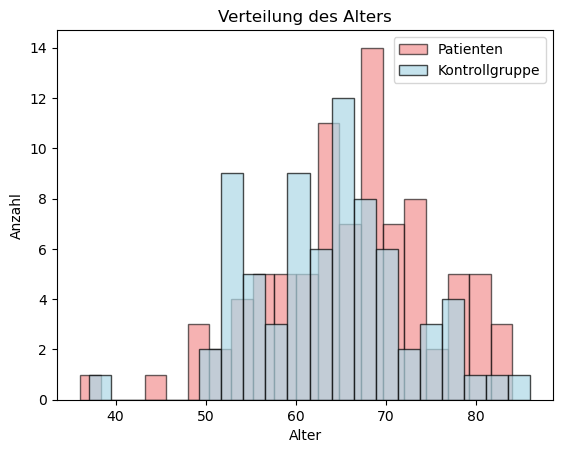

In [26]:
# Verteilung des Alter in PD und CO.
plt.hist(pds_pat.age, bins=20, color="lightcoral", edgecolor="black", alpha=0.6, label="Patienten")
plt.hist(pds_co.age, bins=20, color="lightblue", edgecolor="black", alpha=0.7, label="Kontrollgruppe")
plt.title("Verteilung des Alters")
plt.xlabel("Alter")
plt.ylabel("Anzahl")
plt.legend()
plt.show()

In [27]:
print("Druchschnittsalter Patientengruppe: ", pds_pat["age"].mean().round(2))
print("Druchschnittsalter Kontrollgruppe: ", pds_co["age"].mean().round(2))

Druchschnittsalter Patientengruppe:  66.12
Druchschnittsalter Kontrollgruppe:  63.66


Wir sehen sehr gut, dass die Verteilung des Alters und der Altersdurchschnitt in den beiden Gruppen sehr ähnlich ist und sich somit ein guter Vergleich ziehen lässt.

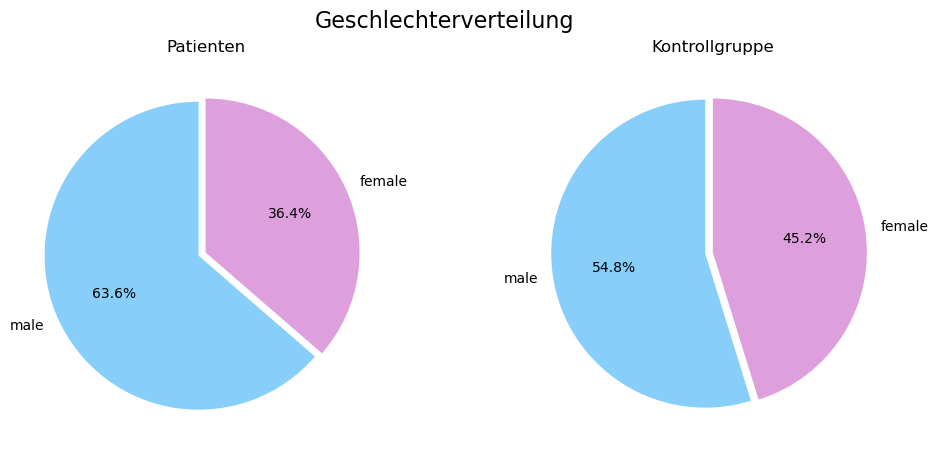

In [28]:
# Verteilung des Geschlechts in PD und CO.
pat_gender_anzahl = pds_pat.gender.value_counts()
co_gender_anzahl = pds_co.gender.value_counts()

fig, axes = plt.subplots(1, 2, sharex = False, figsize = (12, 5))
fig.suptitle("Geschlechterverteilung", fontsize = 16)

axes[0].set(title="Patienten")
axes[0].pie(pat_gender_anzahl, labels = pat_gender_anzahl.index, autopct ='%.1f%%',\
        startangle = 90, explode = [0.05, 0], colors = ['lightskyblue', 'plum'])

axes[1].set(title="Kontrollgruppe")
axes[1].pie(co_gender_anzahl, labels = co_gender_anzahl.index, autopct ='%.1f%%',\
        startangle = 90, explode = [0.05, 0], colors = ['lightskyblue', 'plum'])
plt.show()

Wie eingangs erwähnt, sind v.a. Männer von der Prakinson-Erkrankung betroffen, dies spiegelt sich in der Verteilung der Geschlechter wider.

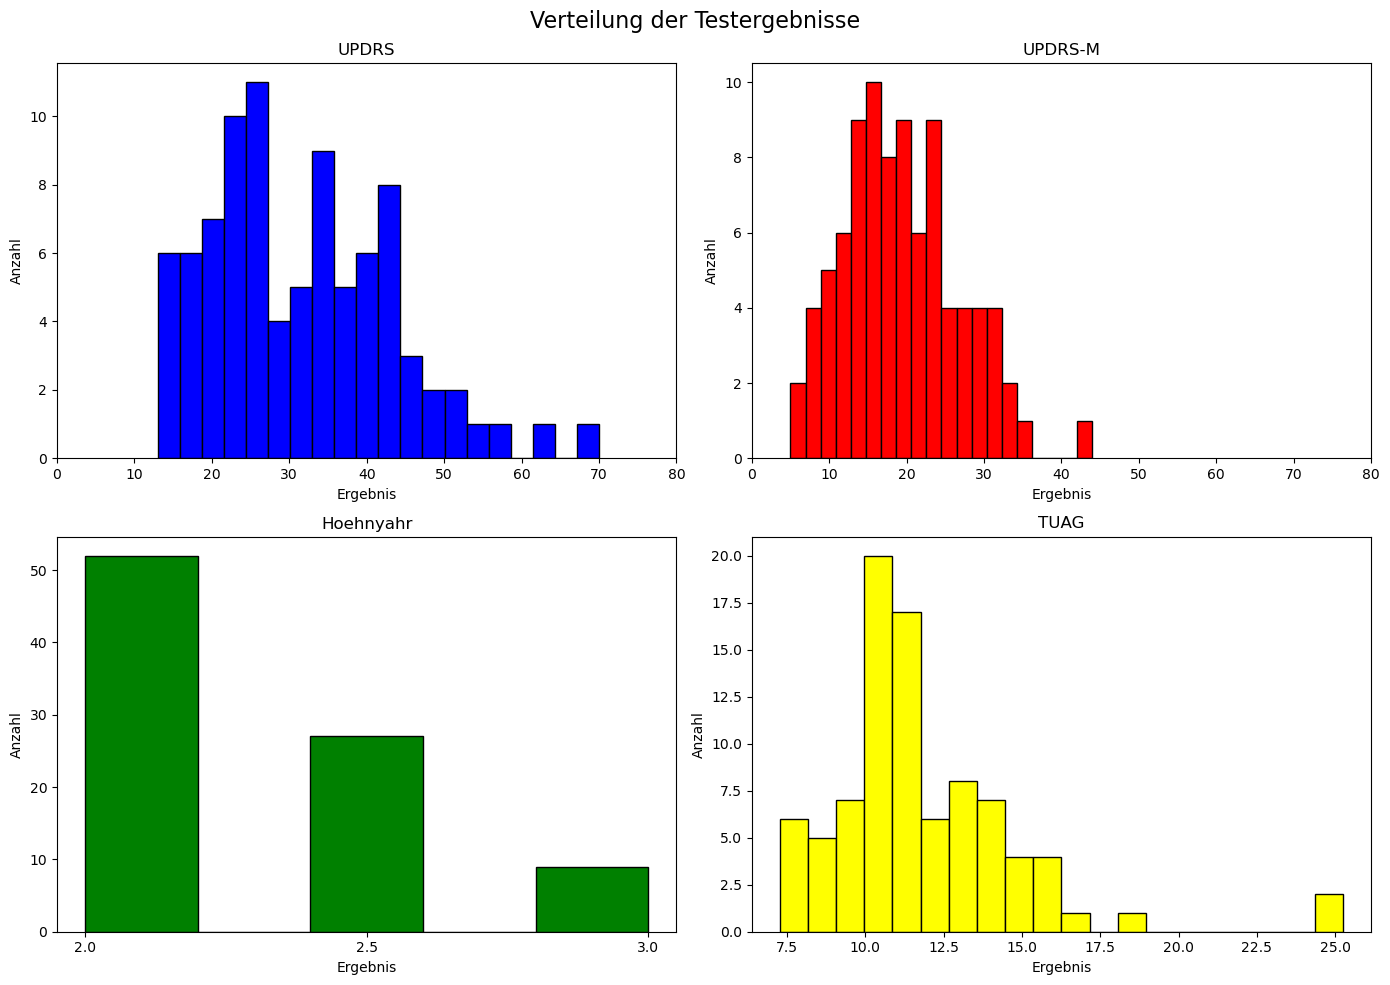

In [29]:
# Verteilung der Testergebnisse.
fig, axes = plt.subplots(2, 2, figsize = (14, 10))
fig.suptitle("Verteilung der Testergebnisse", fontsize = 16)

axes[0][0].hist(pds_pat.updrs, bins=20, color="blue", edgecolor="black")
axes[0][0].set_xticks(np.arange(0, 81, 10))
axes[0][1].hist(pds_pat.updrsm, bins=20, color="red", edgecolor="black")
axes[0][1].set_xticks(np.arange(0, 81, 10))
axes[1][0].hist(pds_pat.hoehnyahr, bins=5, color="green", edgecolor="black")
axes[1][0].set_xticks([2, 2.5, 3])
axes[1][1].hist(pds_pat.tuag, bins=20, color="yellow", edgecolor="black")

axes[0][0].set(title="UPDRS", ylabel="Anzahl", xlabel="Ergebnis")
axes[0][1].set(title="UPDRS-M", ylabel="Anzahl", xlabel="Ergebnis")
axes[1][0].set(title="Hoehnyahr", ylabel="Anzahl", xlabel="Ergebnis")
axes[1][1].set(title="TUAG", ylabel="Anzahl", xlabel="Ergebnis")

plt.tight_layout()
plt.show()

In [30]:
average_tests = pds_pat[["hoehnyahr", "updrs", "updrsm", "tuag"]].mean().round(2).to_frame(name="Durchschnitt")
print(average_tests)

           Durchschnitt
hoehnyahr          2.26
updrs             31.58
updrsm            19.32
tuag              11.79


Alle Verteilungen sind linksschief und auch der Durchschnitt zeigt uns, dass wir es hier mit eher fitteren Patienten zu tun haben.  
Doch um dies zu verdeutlichen, sehen wir uns die Verteilung der Kategorien im TUAG und UPDRS-M an.  
_Da die vier Teile des UPDRS sehr verschiedene Bereich testen, können wir nur eine Einteilung für den motorischen Teil (UPDRS-M) machen und nicht für das Gesamtergebnis._

In [31]:
# Einteilung des TUAG und UPDRS-M in Grade.

pat_tuag_einteilung = pds_pat["grad_tuag"].value_counts().reindex(einteilung_tuag)
pat_tuag_einteilung = pat_tuag_einteilung.to_frame(name="Anzahl")
pat_tuag_einteilung.index.name = None # zur besseren lesbarkeit

pat_updrasm_einteilung = pds_pat["grad_updrsm"].value_counts().reindex(einteilung_updrsm)
pat_updrasm_einteilung = pat_updrasm_einteilung.to_frame(name="Anzahl")
pat_updrasm_einteilung.index.name = None # zur besseren lesbarkeit

co_tuag_einteilung = pds_co["grad_tuag"].value_counts().reindex(einteilung_tuag)
co_tuag_einteilung = co_tuag_einteilung.to_frame(name="Anzahl")
co_tuag_einteilung.index.name = None # zur besseren lesbarkeit

print("Verteilung des TUAGs in Schweregrade bei den Patienten:\n", pat_tuag_einteilung, end="\n\n")
print("Verteilung des UPDRS-M in Schweregrade bei den Patienten:\n", pat_updrasm_einteilung, end="\n\n")
print("Verteilung des TUAGs in Schweregrade in der Kontrollgruppe:\n", co_tuag_einteilung)

Verteilung des TUAGs in Schweregrade bei den Patienten:
         Anzahl
keine       19
leicht      67
mittel       2
schwer       0

Verteilung des UPDRS-M in Schweregrade bei den Patienten:
         Anzahl
leicht      84
mittel       4
schwer       0

Verteilung des TUAGs in Schweregrade in der Kontrollgruppe:
         Anzahl
keine       46
leicht      27
mittel       0
schwer       0


Hier sehen wir, dass sich die linksschiefe Verteilung auch in den Schweregraden widerspiegelt. Gut zu erkennen ist unteranderem auch, dass selbst in der Kontrollgruppe Probanden vorhanden sind, die eine leichte Mobilitätseinschränkung im TUAG zeigen.

<a id="interpretation_dokumentation"></a>
## 4. Interpretation und Dokumentation

Nachdem wir uns einen Überblick über den Datensatz verschafft haben und die Verteilung einiger Variablen gesehen haben, wollen wir nun tiefer eintauchen.  
Im Folgenden sehen wir uns fünf Hypthesen/Fragestellungen an, die wir mit dem Datensatz ergründen möchten.

### **1. Hypothese**   
Mit steigendem Alter sollte sich der Schweregrad der Parkinsonerkrankung erhöhen.
Doch ist dies tatsächlich so und spielt das Geschlecht dabei eine Rolle?

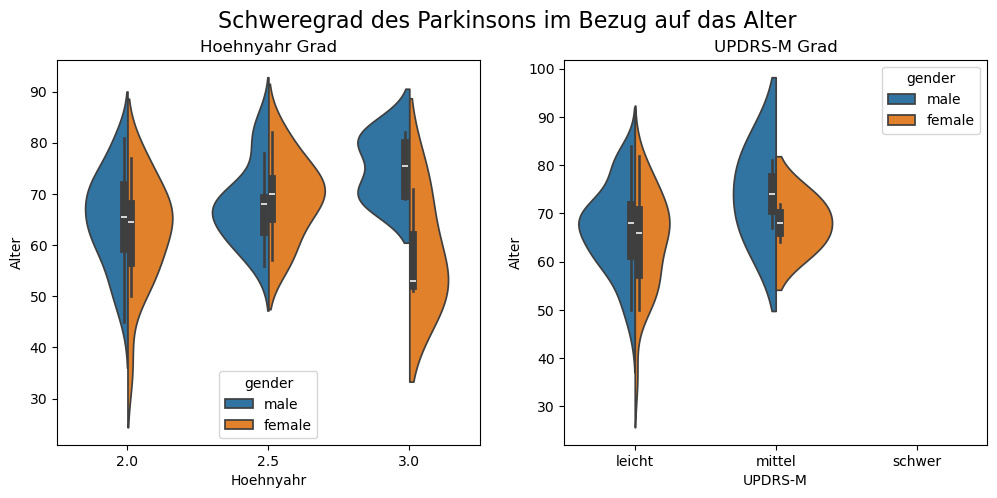

In [32]:
# Violinendiagramm  für den Schweregrad der Parkinsonerkrankungen.
fig, axes = plt.subplots(1, 2, sharex=False, figsize=(12,5))
fig.suptitle("Schweregrad des Parkinsons im Bezug auf das Alter", fontsize = 16)

axes[0].set(title="Hoehnyahr Grad", ylabel="Alter", xlabel="Hoehnyahr")
axes[1].set(title="UPDRS-M Grad", ylabel="Alter", xlabel="UPDRS-M")

sns.violinplot(ax=axes[0], y="age", x="hoehnyahr", data=pds_pat, hue="gender", hue_order=["male", "female"], split=True)
sns.violinplot(y="age", x="grad_updrsm", data=pds_pat, hue="gender", hue_order=["male", "female"], split=True)
plt.show()

Die Violinendiagramme liefern ein paar interessante Ergebnisse:  
Sehen wir uns zuerst den Hoehnyahr Grad an. Bei einer Bewertung von 2.0 sind die Patienten im Durchschnitt um die 65 Jahre alt, hierbei ist die Verteilung der Geschlechter sehr homogen. Doch mit steigendem Grad ändert sich die Verteilung. Im Grad 3.0 sind die männlichen Patienten meist zwischen 70 und 80 Jahren alt. Die weiblichen Patienten sind dagegen eher zwischen 50 und 70. Hier lässt sich also ein Trend bei den Männern sehen, dass mit steigendem Alter auch der Schweregrad steigt, doch bei den Frauen scheint dies nicht der Fall zu sein.  
Der UPDRS-M zeigt einen ähnlichen Trend; auch hier nimmt der Schweregrad bei den Männern mit dem Alter zu. Doch zeigt sich bei den Frauen eine andere Verteilung. Die mittel betroffenden Patientinnen sind alle um die Ende 60, die männlichen Patienten sind hier wieder zwischen 70 und 80.  Bei diesen Beobachtungen sollte bedacht werden, dass hier nur eine kleine Kohorte betrachtet wird und keine Längsschnittstudie zu Grunde liegt. Da Parkinson eine degenerative Erkrankung ist, ist davon auszugehen, dass mit steigendem Alter nach der Erstdiagnose der Schweregrad steigt.

### **2. Hypothese**   
Mit dem Alter nehmen die Muskulatur und Leistungsfähigkeit eines Menschen ab und er wird langsamer. Spiegelt sich dieser natürliche Abbau im „Timend Up and Go“ Test (TUAG) wider?  
Gibt es einen Unterschied bei Menschen mit und ohne Parkinsonerkrankung?

In [33]:
# Bestimmung des r-Wert für "age" & "tuag" PD und CO.
r_wert_pat, _ = stats.pearsonr(pds_pat["age"], pds_pat["tuag"])
r_wert_co, _ = stats.pearsonr(pds_co["age"], pds_co["tuag"])

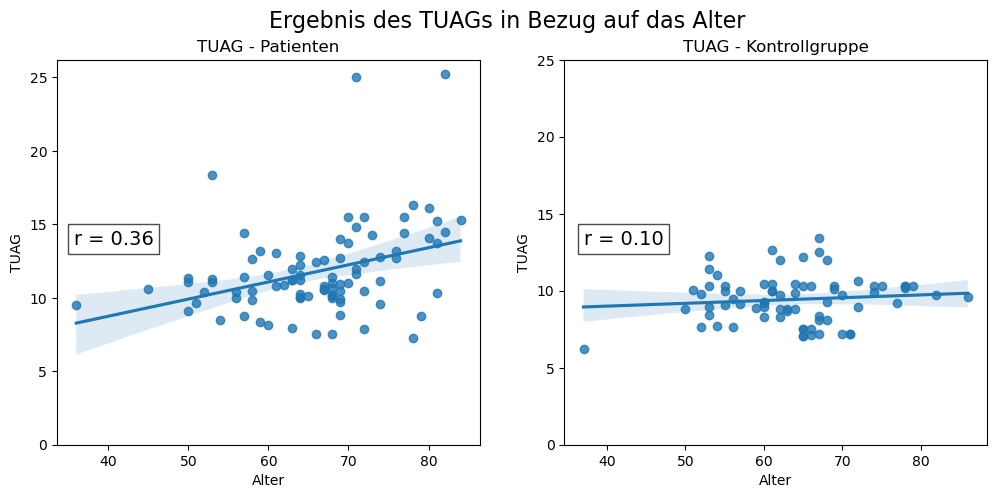

In [34]:
# Regressionsdiagramm für TUAG und Alter.
fig, axes = plt.subplots(1, 2, sharex=False, figsize=(12,5))
fig.suptitle("Ergebnis des TUAGs in Bezug auf das Alter", fontsize = 16)

sns.regplot(ax=axes[0], x="age", y="tuag", data=pds_pat)
axes[0].set_yticks(np.arange(0, 26, 5))
axes[0].set(title="TUAG - Patienten", xlabel="Alter", ylabel="TUAG")
plt.text(x=-28, y=13, s=f"r = {r_wert_pat:.2f}", fontsize=14, 
         bbox=dict(facecolor='white', alpha=0.7))

sns.regplot(ax=axes[1], x="age", y="tuag", data=pds_co)
axes[1].set_yticks(np.arange(0, 26, 5))
axes[1].set(title="TUAG - Kontrollgruppe", xlabel="Alter", ylabel="TUAG")
plt.text(x=37, y=13, s=f"r = {r_wert_co:.2f}", fontsize=14, 
         bbox=dict(facecolor='white', alpha=0.7))
plt.show()

Das Regressionsdiagramm der Patienten zeigt eine leichte Tendenz, dass mit steigendem Alter die Ergebnisse schlechter werden. Der r-Wert von 0.36 zeigt uns aber auch, dass es nur eine moderate positive Korrelation gibt.  
Die Kontrollgruppe zeigt einen noch geringern r-Wert von 0.10, was eine sehr schwache Korrelation bedeutet.  
So lässt sich anhand der Daten zwar zeigen, dass die Ergebnisse der Patienten mit steigendem Alter schlechter werden, vor allem im Vergleich zur Kontrollgruppe. Doch ein genereller Abbau der Mobilität lässt sich mit diesen Daten nicht beweisen.  
Auch hier sei erwähnt, dass der Datensatz nur eine Momentaufnahme darstellt.

### **3. Hypothese**   
Die Körpergröße und das -gewicht haben Einfluss auf die Bewegung der Menschen. Wird dies im TUAG und in der Gehgeschwindigkeit ersichtlich?  
Je schneller jemand gehen kann, umso besser sollte das Ergebnis des TUAG´s ausfallen. Doch ist die Gehgeschwindigkeit wirklich so ein großer Faktor?


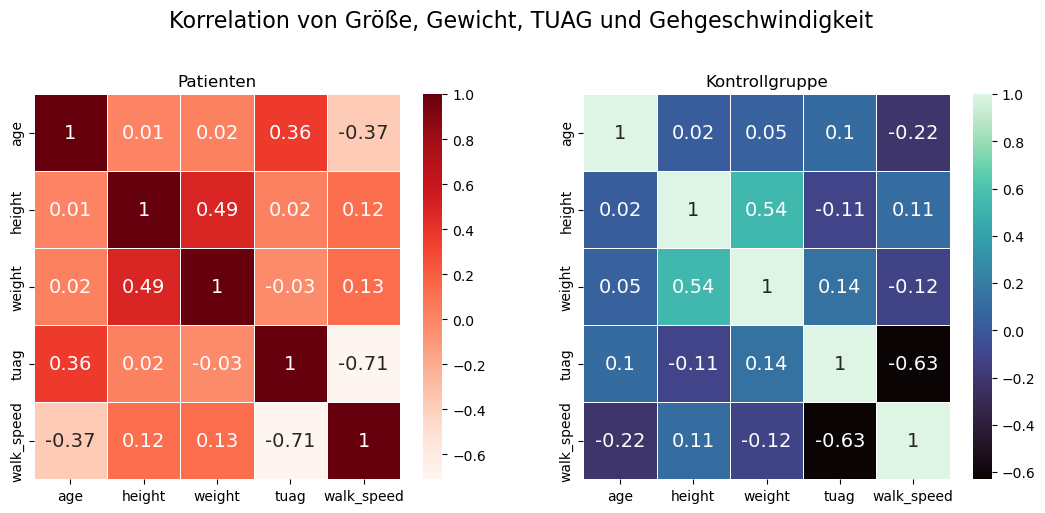

In [35]:
# Heatmap Größe, Alter, TUAG, Gehgeschwindigkeit.
corr_pat = pds_pat[["age", "height", "weight", "tuag", "walk_speed"]].corr().round(2)
corr_co = pds_co[["age", "height", "weight", "tuag", "walk_speed"]].corr().round(2)

fig, axes = plt.subplots(1, 2, sharex=False, figsize=(13,5))
fig.suptitle("Korrelation von Größe, Gewicht, TUAG und Gehgeschwindigkeit", fontsize = 16, y=1.05)

sns.heatmap(ax=axes[0], data=corr_pat, annot=True, linewidths=0.5, cmap='Reds', annot_kws={"size": 14})
axes[0].set(title="Patienten")

sns.heatmap(ax=axes[1], data=corr_co, annot=True, linewidths=0.5, cmap='mako', annot_kws={"size": 14})
axes[1].set(title="Kontrollgruppe")
plt.show()

Die Heatmap der Patienten zeigt eindeutig eine Korrelation zwischen dem TUAG und der Gehgeschwindigkeit. So lässt sich für diesen Datensatz sagen: Umso höher die Gehgeschwindigkeit ist, desto weniger Zeit wurde für den TUAG benötigt. Doch sehen wir hier auch noch drei weitere Trends. Eine offensichtliche Korrelation besteht zwischen der Größe und dem Gewicht, sowie die in der vorangegangene Hypothese gesehene Korrelation zwischen dem Alter und dem Ergebnis des TUAGs. Eine weitere moderate Verbindung lässt sich noch zwischen dem Alter und der Gehgeschwindigkeit entdecken. So nimmt die Geschwindigkeit mit steigendem Alter ab, was die Degeneration der Parkinson-Erkrankung leicht unterstreicht.  
Die Verbindung zwischen der Größe und dem Gewicht, so wie der Gehgeschwindigkeit und dem Ergebnis des TUAGs lassen sich in der Kontrollgruppe auch feststellen. Doch wird auch hier deutlich, wie in der vorherigen Grafik zu sehen, dass die Korrelation zwischen dem TUAG und dem Alter kaum besteht und die Verbindung zum Alter und der Gehgeschwindigkeit auch abgeflacht ist.  
Einen Einfluss von Größe und Gewicht auf den TUAG und die Gehgeschwindigkeit lässt sich nicht ergründen. 
Auch hier müssen wir wieder bedenken, dass die Daten nur eine Momentaufnahme darstellen.

### **4. Hypothese**   
Inwieweit findet sich bei der Betrachtung der vier Test eine Korrelation?

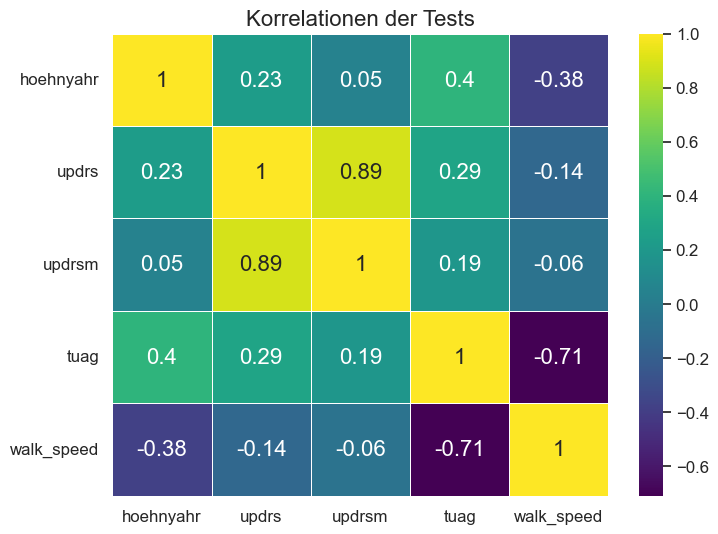

In [36]:
# Heatmap aller Testergebnisse.
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.1)
heatmap = sns.heatmap(data=pds_pat[["hoehnyahr", "updrs", "updrsm", "tuag", "walk_speed"]].corr().round(2),
            annot=True, linewidths=0.5, cmap='viridis', annot_kws={"size": 16})
plt.title("Korrelationen der Tests", fontsize = 16)
heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=0)
plt.show()

Auch hier ist nochmal die Korrelation ziwschen TUAG und der Gehgeschwindigkeit ersichtlich. Doch noch größer ist die Korrelation zwischen dem Gesamtergebnis des UPDRS und dem UPDRS-M. Dies ist natürlich verständlich, da der UPDRS-M ein Teil des UPDRS ist. Dennoch wollen wir kurz kontrollieren, ob sich eventuell Fehler in den Datensatz eingeschlichen haben und es Fälle gibt, in denen das Gesamtergebnis unter dem Ergebnis des UPDRS-M liegt.

In [37]:
vergleich_updrs = pds_pat[pds_pat["updrs"] <= pds_pat["updrsm"]]
print("Geht es fehlerhafte Einträge, bei dem der UPDRS kleiner als der UPRDS-M ist? \nAnzahl der Fehler: ",len(vergleich_updrs))

Geht es fehlerhafte Einträge, bei dem der UPDRS kleiner als der UPRDS-M ist? 
Anzahl der Fehler:  0


Die Daten sind korrekt.  
Doch ist in der Heatmap noch eine weiter Korrelation ersichtlich. Die Hoehnyahr Skala wird moderat negativ von der Gehgeschwindigkeit und positiv vom TUAG beeinflusst. So kann bei sinkender Gehgeschwindigkeit und steigendem TUAG-Ergebnis ein leicht erhöhter Schweregrad in der Hoehnyahr Skala beobachtet werden.  

### **5. Hypothese**   
Lässt sich anhand der Kategorie im TUAG auf die Einteilung im UPDRS-M und umgekehrt schließen?

In [38]:
# Vergleich der Einteilungen für TUAG und UPDRS-M.
kategorie_tuag_updrsm = pds_pat.groupby(["grad_tuag", "grad_updrsm"]).size().reset_index(name="Anzahl")
kategorie_tuag_updrsm

,grad_tuag,grad_updrsm,Anzahl
0,keine,leicht,19
1,leicht,leicht,63
2,leicht,mittel,4
3,mittel,leicht,2


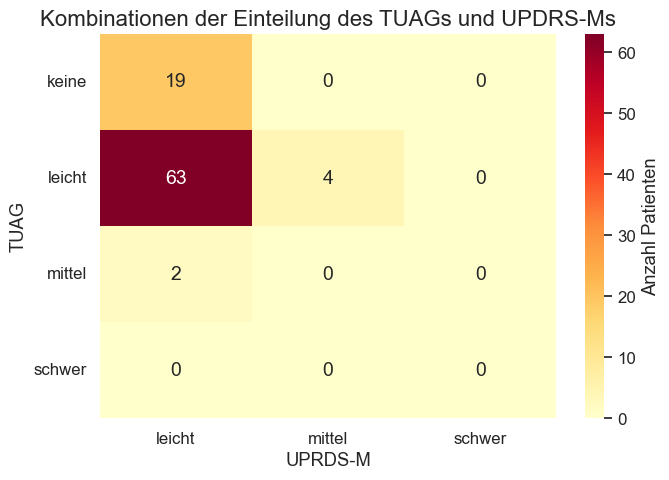

In [39]:
# Heatmap Vergleich TUAG und UPDRS-M.
heatmap_kategorie = (kategorie_tuag_updrsm.pivot(index="grad_tuag", columns="grad_updrsm", values="Anzahl")\
                     .reindex(index=einteilung_tuag, columns=einteilung_updrsm).fillna(0)
                     )
plt.figure(figsize=(7, 5))
sns.set(font_scale=1.1)
heatmap = sns.heatmap(heatmap_kategorie, annot=True, annot_kws={"size": 14}, fmt=".0f", cmap="YlOrRd", cbar_kws={"label": "Anzahl Patienten"})
plt.title("Kombinationen der Einteilung des TUAGs und UPDRS-Ms", fontsize = 16)
plt.xlabel("UPRDS-M")
plt.ylabel("TUAG")
heatmap.set_yticklabels(heatmap.get_yticklabels(), rotation=0)
plt.tight_layout()
plt.show()

Wir sehen, dass die Verteilung im Datzensatz für 63 Patienten im TUAG und im UPDRS-M einen leichten Schweregrad zeigt. Doch zeigt dies uns lediglich, dass im Datensatz sehr viele leicht betroffene Patienten sind. Um eine wirkliche Verbindung zwischen den Tests zu berechnen, sind weitere Tests notwendig.  
Außerdem sind die getesteten Fähigkeiten in beiden Tests nicht identisch. Der TUAG fragt die eigenständige Mobilität ab und der UPDRS-M einzelne Bewegungen und Aspekte des Muskeltonus. Daher lassen sich die Tests nur bedingt gut vergleichen.  
Somit ist eine Korrelation der Grade eher unwahrscheinlich.

Ein möglicher Test wäre der Fisher's Exakter Test:  
> `from scipy.stats import fisher_exact`  
>
> `daten = heatmap_kategorie.to_numpy()`  
`maske_zeilen = ~np.all(daten == 0, axis=1)`  
`maske_spalten = ~np.all(daten == 0, axis=0)`  
`bereinigte_daten = daten[maske_zeilen][:, maske_spalten]`  
>  
> `res = fisher_exact(bereinigte_daten)`  
>  
> `print(f"p-Wert: {res.pvalue:.4f}")`  
>  
> `if res.pvalue < 0.05:`  
    `print("Ergebnis ist signifikant. Es gibt einen statistischen Zusammenhang.")`  
`else:`  
    `print("Ergebnis ist NICHT signifikant. Es gibt keinen nachweisbaren Zusammenhang.")`  

In [40]:
from scipy.stats import fisher_exact

daten = heatmap_kategorie.to_numpy()
maske_zeilen = ~np.all(daten == 0, axis=1)
maske_spalten = ~np.all(daten == 0, axis=0)
bereinigte_daten = daten[maske_zeilen][:, maske_spalten]
res = fisher_exact(bereinigte_daten)
  
print(f"p-Wert: {res.pvalue:.4f}")
  
if res.pvalue < 0.05:
    print("Ergebnis ist signifikant. Es gibt einen statistischen Zusammenhang.")
else:  
    print("Ergebnis ist NICHT signifikant. Es gibt keinen nachweisbaren Zusammenhang.")

p-Wert: 0.6163
Ergebnis ist NICHT signifikant. Es gibt keinen nachweisbaren Zusammenhang.


<a id="schlussfolgerungen"></a>
## 5. Schlussfolgerungen

**Zusammenfassung:**  
Nach der intensiven Arbeit mit dem Datensatz konnten wir folgende Beobachtungen machen:  
Dass die Parkinson-Erkrankung v.a. männliche Patienten betrifft, konnten wir gut sehen (63.6%), vor allem in Hinblick auf die Kontrollgruppe (54.8%). Im Wesentlichen waren im Datensatz nur leicht betroffene Patienten vertreten, bei denen die Selbständigkeit erhalten war.  
Eine Verbindung zwischen dem Alter und dem Schweregrad der Patienten konnten wir bedingt feststellen. Hier waren vor allem die männlichen Patienten mit steigendem Alter in höheren Schweregraden angesiedelt. Da in den Studien nur einmal eine Erhebung der Daten stattfand, konnten wir nur die Verteilung im Datensatz betrachten und nicht einen Vergleich über einen Zeitraum erstellen.  
Die Korrelation zwischen dem Alter und dem TUAG fiel bei den Patienten moderat aus. In der Kontrollgruppe war keine Korrelation festzustellen.  
Die Zusammenhänge von Personendaten und Testergebnissen zeigten ein paar interessante Ergebnisse.  
So ließ sich klar erkennen, dass sich TUAG-Ergebnis und Gehgeschwindigkeit bedingen. Je schneller jemand geht, umso besser ist das Ergebnis im TUAG. Die Verbindung zwischen dem Gesamtergebnis des UPDRS und dem motorischen Teil war offensichtlich, doch haben wir hier nochmal auf Fehler im Datensatz geprüft. Eine weitere offensichtliche Verbindung von Größe und Gewicht bestätigte der Datensatz auch.

Bei der Bereinigung des Datensatzes wurde schnell klar, wie wichtig eine konstante Maßeinheit ist. Da die Werte aus drei Studien zusammengetragen wurden, wäre hierbei vorab eine Angleichung aller Messwerte auf die gleiche Maßeinheit wichtig gewesen. Die fehlenden Werte in den Testergebnissen haben wir aufgrund der Vermutung, dass alle Probanden in der Kontrollgruppe gesund sind, hinzugefügt. Jedoch wären hier reale Ergebnisse spannend gewesen, um eventuelle Auffälligkeiten in der Kontrollgruppe zu untersuchen und einen genaueren Vergleich zur Patientengruppe zu ermöglichen.

**Empfehlungen:**  
Da die Kohorte des Datensatzes mit 161 Probanden tendenziell klein ist, lassen sich somit keine signifikanten Vergleiche zur gesamten Bevölkerung ziehen. Dennoch zeigt der Datensatz Korrelationen, die in größeren Kohorten untersucht werden sollten. Zusätzlich wäre eine Längsschnittstudie der Patienten interessant, um den Verlauf der Parkinson-Erkrankung und den Vergleich zu gesunden Menschen zu ziehen. So könnten noch detailliertere Erkenntnisse gewonnen werden und klare Präventionsmaßnahmen abgeleitet werden.

## Quellen:  
Datensatz:
> Goldberger, A., Amaral, L., Glass, L., Hausdorff, J., Ivanov, P. C., Mark, R., ... & Stanley, H. E. (2000). PhysioBank, PhysioToolkit, and PhysioNet: Components of a new research resource for complex physiologic signals. Circulation [Online]. 101 (23), pp. e215–e220. RRID:SCR_007345.

Parkinson-Erkrankung:
> Koschel, J. Ist eine Parkinson-Demenz bei langjährig Erkrankten seltener als bisher gedacht? DNP 21, 20 (2020).

UPDRS:  
> https://www.movementdisorders.org/MDS-Files1/PDFs/MDS-UPDRS-Rating-Scales/MDS-UPDRS_German_Official_Translation_FINAL.pdf, abgerufen am 11.06.2026